In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
client_path = os.path.join("data", "client_data.csv")
df_client = pd.read_csv(client_path)
print(df_client.head(3))

client_path = os.path.join("data", "price_data.csv")
df_price = pd.read_csv(client_path)
print(df_price.head(3))

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   

  date_modif_prod date_renewal  forecast_cons_12m  ...  has_gas  imp_cons  \
0      2015-11-01   2015-06-23               0.00  ...        t       0.0   
1      2009-08-21   2015-08-31             189.95  ...        f       0.0   
2      2010-04-16   2015-04-17              47.96  ...        f       0.0   

   margin_gross_pow_ele  margin_net_pow_ele  nb_prod_act  net_margin  \
0                 25.44               25.44  

In [3]:
client_subset =df_client[['id', 'churn', 'date_modif_prod']]


# Step 2: Merge the subset into the price dataframe using 'id' as the key
merged_price_df = pd.merge(df_price, client_subset, on='id', how='left')

# View the updated pricing dataframe
print(merged_price_df.head())

                                 id  price_date  price_off_peak_var  \
0  038af19179925da21a25619c5a24b745  2015-01-01            0.151367   
1  038af19179925da21a25619c5a24b745  2015-02-01            0.151367   
2  038af19179925da21a25619c5a24b745  2015-03-01            0.151367   
3  038af19179925da21a25619c5a24b745  2015-04-01            0.149626   
4  038af19179925da21a25619c5a24b745  2015-05-01            0.149626   

   price_peak_var  price_mid_peak_var  price_off_peak_fix  price_peak_fix  \
0             0.0                 0.0           44.266931             0.0   
1             0.0                 0.0           44.266931             0.0   
2             0.0                 0.0           44.266931             0.0   
3             0.0                 0.0           44.266931             0.0   
4             0.0                 0.0           44.266931             0.0   

   price_mid_peak_fix  churn date_modif_prod  
0                 0.0    0.0      2015-04-29  
1               

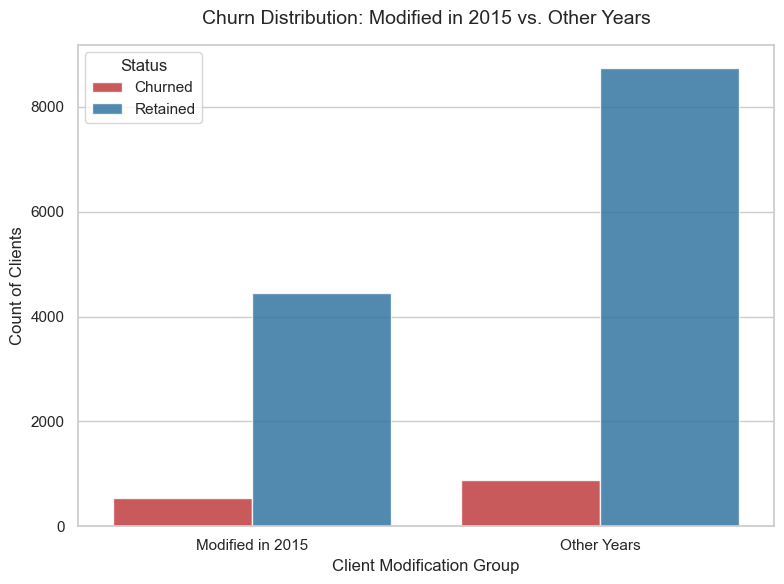

--- Exact Breakdown ---
Status              Churned  Retained
Modification Group                   
Modified in 2015        534      4440
Other Years             885      8747

--- Churn Rate Comparison ---
Modification Group
Modified in 2015    10.735826
Other Years          9.188123
Name: churn, dtype: float64


In [12]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create a flag column: True if the year is 2015, False otherwise
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015

# 3. Map the flag and churn status to clean text labels for the plot
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})
df_client['Status'] = df_client['churn'].map({0: 'Retained', 1: 'Churned'})

# 4. Generate the count plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.countplot(
    data=df_client,
    x='Modification Group',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85
)

# 5. Add titles and labels
plt.title('Churn Distribution: Modified in 2015 vs. Other Years', fontsize=14, pad=15)
plt.xlabel('Client Modification Group', fontsize=12)
plt.ylabel('Count of Clients', fontsize=12)
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# Optional: Print out the exact numbers and churn rates for both groups
print("--- Exact Breakdown ---")
print(pd.crosstab(df_client['Modification Group'], df_client['Status']))

print("\n--- Churn Rate Comparison ---")
print(df_client.groupby('Modification Group')['churn'].mean() * 100)

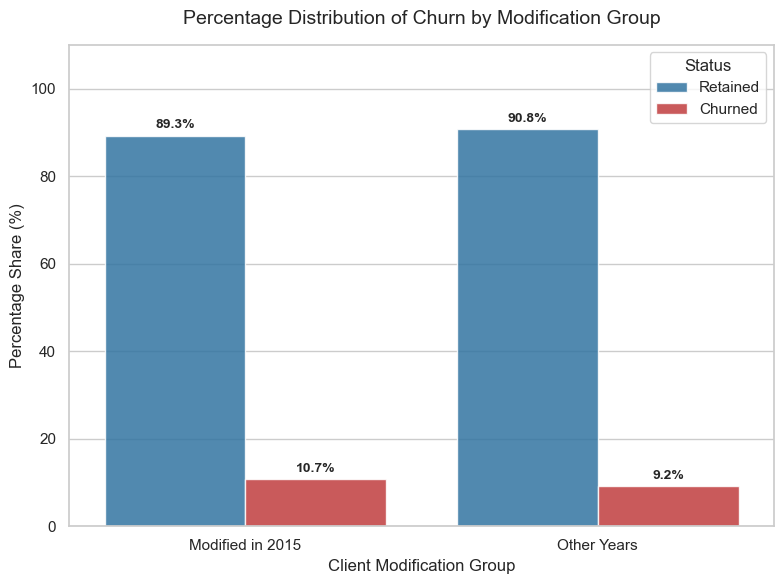

--- Percentage Distribution Matrix ---
churn                       0          1
Modification Group                      
Modified in 2015    89.264174  10.735826
Other Years         90.811877   9.188123


In [13]:


# 1. Ensure date_modif_prod is in datetime format
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create the modification flag and human-readable groups
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

# 3. Compute the normalized percentages (relative to each group)
# This calculates the exact % of Churned vs Retained *within* each modification category
percentage_data = (
    df_client.groupby('Modification Group')['churn']
    .value_counts(normalize=True)
    .rename('Percentage')
    .reset_index()
)

# Convert the 0/1 churn markers into readable text labels for the plot
percentage_data['Status'] = percentage_data['churn'].map({0: 'Retained', 1: 'Churned'})
percentage_data['Percentage'] *= 100  # Convert fractions (0.90) to clean percentages (90.0)

# 4. Generate the percentage-based distribution plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=percentage_data,
    x='Modification Group',
    y='Percentage',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85
)

# 5. Annotate the exact percentages directly on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10, weight='bold')

# 6. Clean up labels and presentation
plt.title('Percentage Distribution of Churn by Modification Group', fontsize=14, pad=15)
plt.xlabel('Client Modification Group', fontsize=12)
plt.ylabel('Percentage Share (%)', fontsize=12)
plt.ylim(0, 110)  # Add breathing room for the top text labels
plt.legend(title='Status')

plt.tight_layout()
plt.show()

# Print the final matrix breakdown to the console
print("--- Percentage Distribution Matrix ---")
print(pd.crosstab(df_client['Modification Group'], df_client['churn'], normalize='index') * 100)

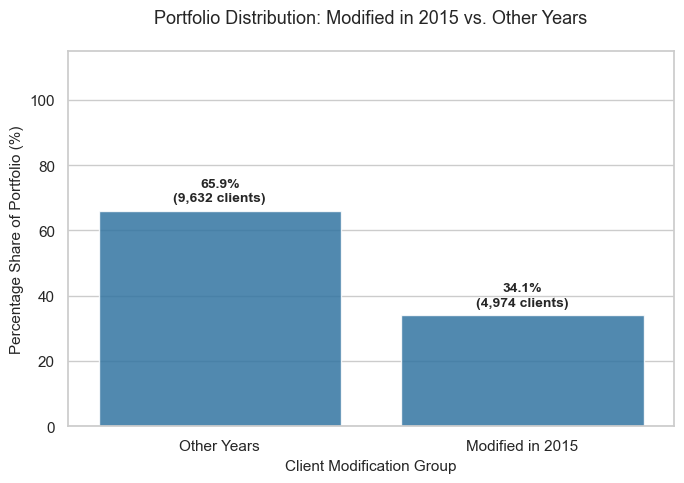

--- Portfolio Distribution Summary ---
Modification Group  Count  Percentage
       Other Years   9632   65.945502
  Modified in 2015   4974   34.054498


In [14]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Create the modification flag and human-readable groups
df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

# 3. Calculate both the raw counts and the percentage distribution
group_counts = df_client['Modification Group'].value_counts()
group_percentages = df_client['Modification Group'].value_counts(normalize=True) * 100

# Combine them into a clean summary DataFrame for plotting
summary_df = pd.DataFrame({
    'Count': group_counts,
    'Percentage': group_percentages
}).reset_index().rename(columns={'index': 'Modification Group'})

# 4. Generate the percentage-based distribution plot
plt.figure(figsize=(7, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=summary_df,
    x='Modification Group',
    y='Percentage',
    color='#1f77b4',  # Uniform blue color since we aren't splitting by churn
    edgecolor='white',
    alpha=0.85
)

# 5. Annotate the bars with BOTH the percentage and the raw client count
for i, bar in enumerate(ax.patches):
    # Get the corresponding count and percentage values
    pct = summary_df.loc[i, 'Percentage']
    count = summary_df.loc[i, 'Count']
    
    # Create a clean label text showing both metrics
    label_text = f"{pct:.1f}%\n({count:,} clients)"
    
    # Place the text on top of each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# 6. Clean up labels and presentation
plt.title('Portfolio Distribution: Modified in 2015 vs. Other Years', fontsize=13, pad=20)
plt.xlabel('Client Modification Group', fontsize=11)
plt.ylabel('Percentage Share of Portfolio (%)', fontsize=11)
plt.ylim(0, 115)  # Add extra headroom for the text blocks

plt.tight_layout()
plt.show()

# Print the clean summary table directly to your console
print("--- Portfolio Distribution Summary ---")
print(summary_df.to_string(index=False))

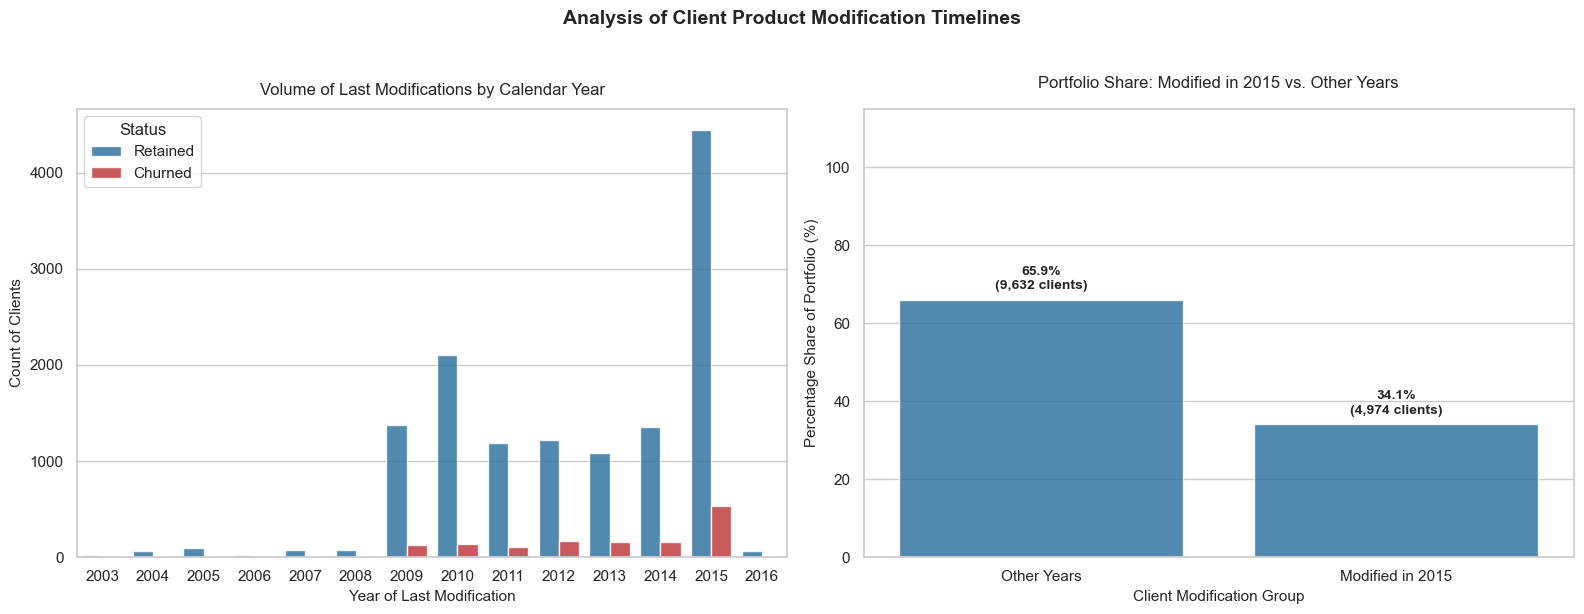

In [23]:
# 1. Ensure date_modif_prod is in datetime format
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Engineer the year and group features
df_client['year_modif'] = df_client['date_modif_prod'].dt.year

df_client['modified_in_2015'] = df_client['date_modif_prod'].dt.year == 2015
df_client['Modification Group'] = df_client['modified_in_2015'].map({True: 'Modified in 2015', False: 'Other Years'})

df_client['Status'] = df_client['churn'].map({0: 'Retained', 1: 'Churned'})

# 3. Calculate metrics for the right-side summary plot
group_counts = df_client['Modification Group'].value_counts()
group_percentages = df_client['Modification Group'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': group_counts,
    'Percentage': group_percentages
}).reset_index().rename(columns={'index': 'Modification Group'})

# 4. Set up a 1-row, 2-column subplot figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- LEFT PLOT: Whole-Year Count Distribution ---
sns.countplot(
    data=df_client,
    x='year_modif',
    hue='Status',
    palette={'Retained': '#1f77b4', 'Churned': '#d62728'},
    edgecolor='white',
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title('Volume of Last Modifications by Calendar Year', fontsize=12, pad=10)
axes[0].set_xlabel('Year of Last Modification', fontsize=11)
axes[0].set_ylabel('Count of Clients', fontsize=11)
axes[0].legend(title='Status')

# --- RIGHT PLOT: 2015 Portfolio Share Percentage ---
ax2 = sns.barplot(
    data=summary_df,
    x='Modification Group',
    y='Percentage',
    color='#1f77b4',
    edgecolor='white',
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title('Portfolio Share: Modified in 2015 vs. Other Years', fontsize=12, pad=15)
axes[1].set_xlabel('Client Modification Group', fontsize=11)
axes[1].set_ylabel('Percentage Share of Portfolio (%)', fontsize=11)
axes[1].set_ylim(0, 115)

# Add both percentage and client counts on top of the right bars
for i, bar in enumerate(ax2.patches):
    pct = summary_df.loc[i, 'Percentage']
    count = summary_df.loc[i, 'Count']
    label_text = f"{pct:.1f}%\n({count:,} clients)"
    
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# 5. Global polishing and display
plt.suptitle('Analysis of Client Product Modification Timelines', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Modification_Timelines_chart.png', bbox_inches='tight')
plt.show()


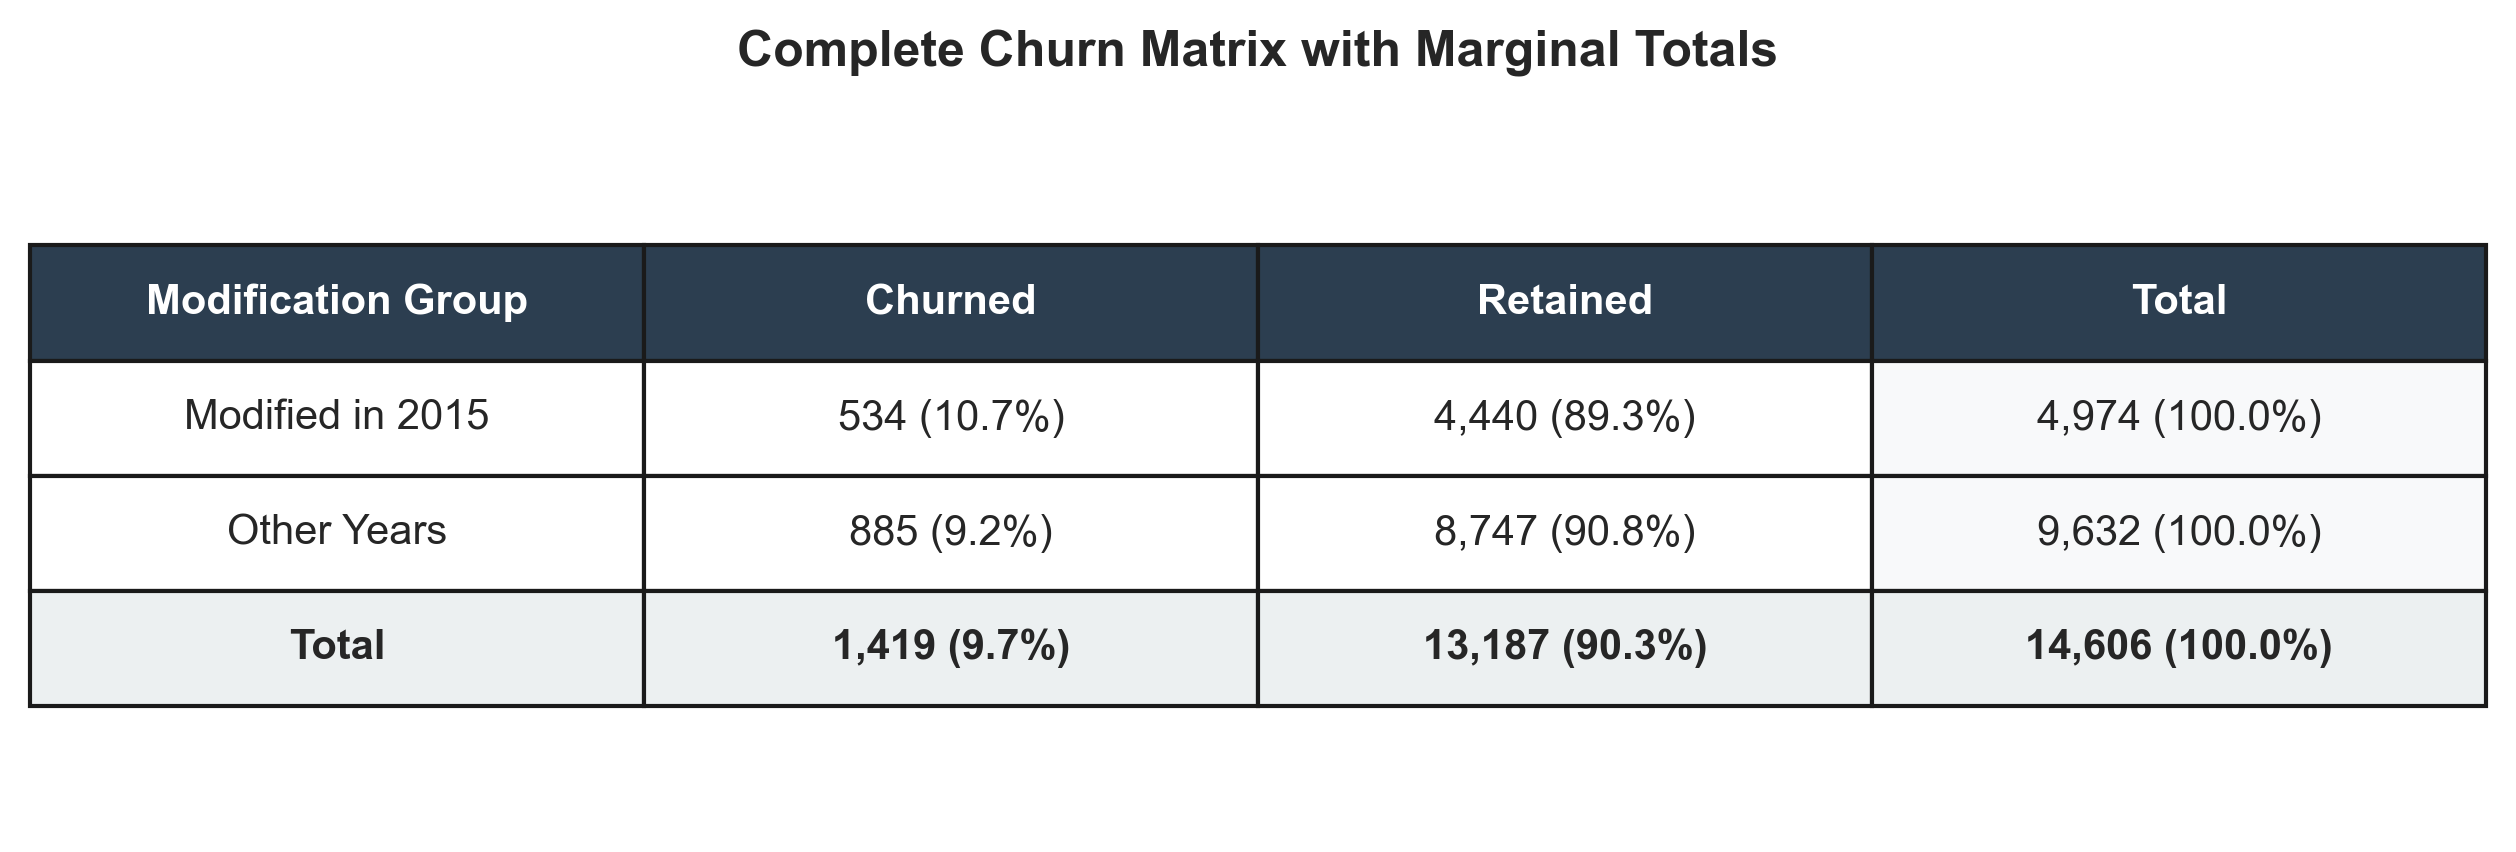

In [22]:


# 1. Structure the raw data into a DataFrame to easily calculate margins and totals
matrix_data = {
    'Churned': [534, 885],
    'Retained': [4440, 8747]
}
df_matrix = pd.DataFrame(matrix_data, index=['Modified in 2015', 'Other Years'])

# 2. Compute marginal row and column totals dynamically
df_matrix['Total'] = df_matrix['Churned'] + df_matrix['Retained']
total_row = pd.Series({
    'Churned': df_matrix['Churned'].sum(),
    'Retained': df_matrix['Retained'].sum(),
    'Total': df_matrix['Total'].sum()
}, name='Total')
df_matrix = pd.concat([df_matrix, total_row.to_frame().T])

# 3. Format the cells to display "Count (Percentage)" relative to their group total
formatted_cells = []
for idx, row in df_matrix.iterrows():
    row_total = row['Total']
    
    # Calculate group-specific percentages
    churn_pct = (row['Churned'] / row_total) * 100
    ret_pct = (row['Retained'] / row_total) * 100
    
    # Append the formatted string rows
    if idx == 'Total':
        # Overall portfolio baseline percentages
        formatted_cells.append([
            idx, 
            f"{row['Churned']:,} ({churn_pct:.1f}%)", 
            f"{row['Retained']:,} ({ret_pct:.1f}%)", 
            f"{row['Total']:,} (100.0%)"
        ])
    else:
        # Group-specific split percentages
        formatted_cells.append([
            idx, 
            f"{row['Churned']:,} ({churn_pct:.1f}%)", 
            f"{row['Retained']:,} ({ret_pct:.1f}%)", 
            f"{row['Total']:,} (100.0%)"
        ])

columns = ["Modification Group", "Churned", "Retained", "Total"]

# 4. Initialize the Matplotlib plot window
fig, ax = plt.subplots(figsize=(8.5, 3), dpi=300)
ax.axis('off')

# 5. Render the table grid inside the plot window
table = ax.table(
    cellText=formatted_cells,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

# 6. Apply professional clean styling and cell scaling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.3)

# Highlight headers and bottom total rows structurally
for (row, col), cell in table.get_celld().items():
    if row == 0:
        # Header Row Styling
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    elif row == len(formatted_cells):
        # Marginal Total Row Styling
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#ecf0f1')
    elif col == 3:
        # Marginal Total Column Background Accent
        cell.set_facecolor('#f8f9fa')

plt.title('Complete Churn Matrix with Marginal Totals', fontsize=12, pad=15, weight='bold')
plt.tight_layout()
plt.savefig('Modification_Timelines.png', bbox_inches='tight')

plt.show()



In [29]:
df_client['date_modif_prod'] = pd.to_datetime(df_client['date_modif_prod'])

# 2. Filter rows where the year component equals 2015
df_2015_clients = df_client[df_client['date_modif_prod'].dt.year == 2015]

# View the filtered subset
print(f"Total clients modified in 2015: {len(df_2015_clients)}")
print(df_2015_clients.head())

Total clients modified in 2015: 4974
                                  id  cons_12m  cons_gas_12m  cons_last_month  \
0   24011ae4ebbe3035111d65fa7c15bc57         0         54946                0   
5   1aa498825382410b098937d65c4ec26d      8302             0             1998   
9   10c1b2f97a2d2a6f10299dc213d1a370     26064             0             2188   
13  21860c2ff2d5df75503b230ce629c253      7726             0                0   
22  78014630fbac3e6aa980361d25cea748     20560             0             3804   

    date_activ    date_end date_modif_prod date_renewal  forecast_cons_12m  \
0   2013-06-15  2016-06-15      2015-11-01   2015-06-23               0.00   
5   2011-12-09  2016-12-09      2015-11-01   2015-12-10             796.94   
9   2010-05-04  2016-05-04      2015-04-29   2015-05-05            2738.10   
13  2013-01-22  2017-01-22      2015-11-18   2016-01-24             914.10   
22  2012-12-31  2016-12-31      2015-11-01   2016-01-01            3037.82   

    for

C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2576251962.py:6: SettingWithCopyWarning: 
A value is trying to be set o

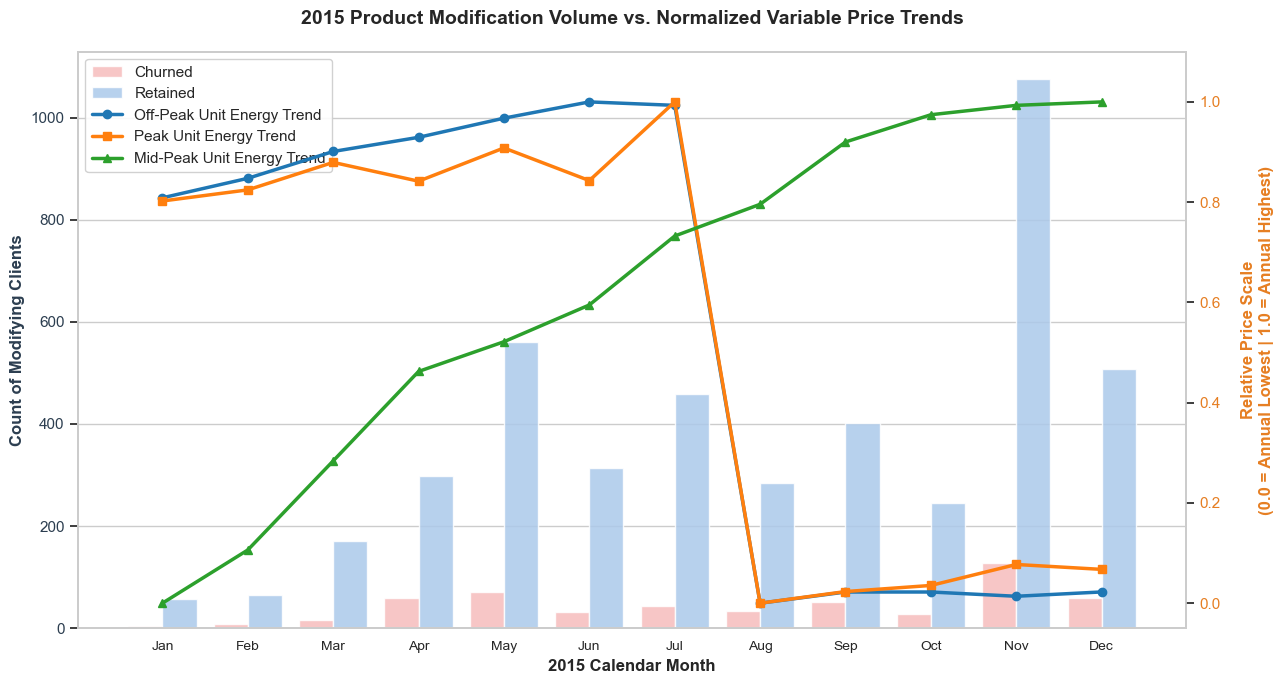

In [27]:


# =====================================================================
# STEP 1: Process the 2015 Client Modification Volume (Bar Data)
# =====================================================================
df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
df_2015_clients['Status'] = df_2015_clients['churn'].map({0: 'Retained', 1: 'Churned'})

# Create a uniform monthly index (1 to 12) for counting modifications
monthly_counts = (
    df_2015_clients.groupby(['month_modif', 'Status'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)

# =====================================================================
# STEP 2: Process and Normalize the Price Trend Data (Line Data)
# =====================================================================
var_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']
df_var_only = df_price[['id', 'price_date'] + var_cols].copy()

# Exclude 0 values to protect baseline averages
for col in var_cols:
    df_var_only[col] = df_var_only[col].replace(0, float('nan'))

# Group by billing date and sort
monthly_var_averages = df_var_only.groupby('price_date')[var_cols].mean().reset_index()
monthly_var_averages = monthly_var_averages.sort_values('price_date')

# Map the price rows to matching months (1 to 12) to align with our bars
monthly_var_averages['price_date'] = pd.to_datetime(monthly_var_averages['price_date'])
monthly_var_averages['Month_Num'] = monthly_var_averages['price_date'].dt.month

# Apply Min-Max Normalization
monthly_var_normalized = monthly_var_averages.copy()
for col in var_cols:
    col_min = monthly_var_averages[col].min()
    col_max = monthly_var_averages[col].max()
    if col_max != col_min:
        monthly_var_normalized[col] = (monthly_var_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_var_normalized[col] = 0.0

# Ensure the price trends are grouped and indexed exactly 1 to 12
monthly_var_normalized = monthly_var_normalized.set_index('Month_Num').reindex(range(1, 13))

# =====================================================================
# STEP 3: Build the Dual-Axis Combined Plot
# =====================================================================
fig, ax1 = plt.subplots(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# --- Primary Axis (Left Y-Axis): Modification Volume Bars ---
# Reset index for compatibility with seaborn's melting structure
bar_data = monthly_counts.reset_index().melt(id_vars='month_modif', value_name='Count')

sns.barplot(
    data=bar_data,
    x='month_modif',
    y='Count',
    hue='Status',
    palette={'Retained': '#a1c9f4', 'Churned': '#ffb3b3'}, # Muted bar colors to let lines pop
    edgecolor='white',
    alpha=0.85,
    ax=ax1
)

ax1.set_ylabel('Count of Modifying Clients', fontsize=12, weight='bold', color='#2c3e50')
ax1.set_xlabel('2015 Calendar Month', fontsize=12, weight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.get_legend().remove() # Move the legend later to a unified window

# --- Secondary Axis (Right Y-Axis): Price Trend Lines ---
ax2 = ax1.twinx()

# Subtract 1 from the x positions (0 to 11) to perfectly align line points with the bar groups
x_positions = [x for x in range(12)]

ax2.plot(x_positions, monthly_var_normalized['price_off_peak_var'], marker='o', linewidth=2.5, color='#1f77b4', label='Off-Peak Unit Energy Trend')
ax2.plot(x_positions, monthly_var_normalized['price_peak_var'], marker='s', linewidth=2.5, color='#ff7f0e', label='Peak Unit Energy Trend')
ax2.plot(x_positions, monthly_var_normalized['price_mid_peak_var'], marker='^', linewidth=2.5, color='#2ca02c', label='Mid-Peak Unit Energy Trend')

ax2.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest | 1.0 = Annual Highest)', fontsize=12, weight='bold', color='#e67e22', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#e67e22')
ax2.set_ylim(-0.05, 1.1) # Extra space at the top to prevent overlapping
ax2.grid(False) # Turn off right grid to keep the background clean

# --- Formatting Labels & Legend ---
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, fontsize=10)

# Merge legends from both axes cleanly
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('2015 Product Modification Volume vs. Normalized Variable Price Trends', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('combined_modification_and_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
C:\Users\yuqin\AppData\Local\Temp\ipykernel_59340\2699814060.py:3: SettingWithCopyWarning: 
A value is trying to be set o

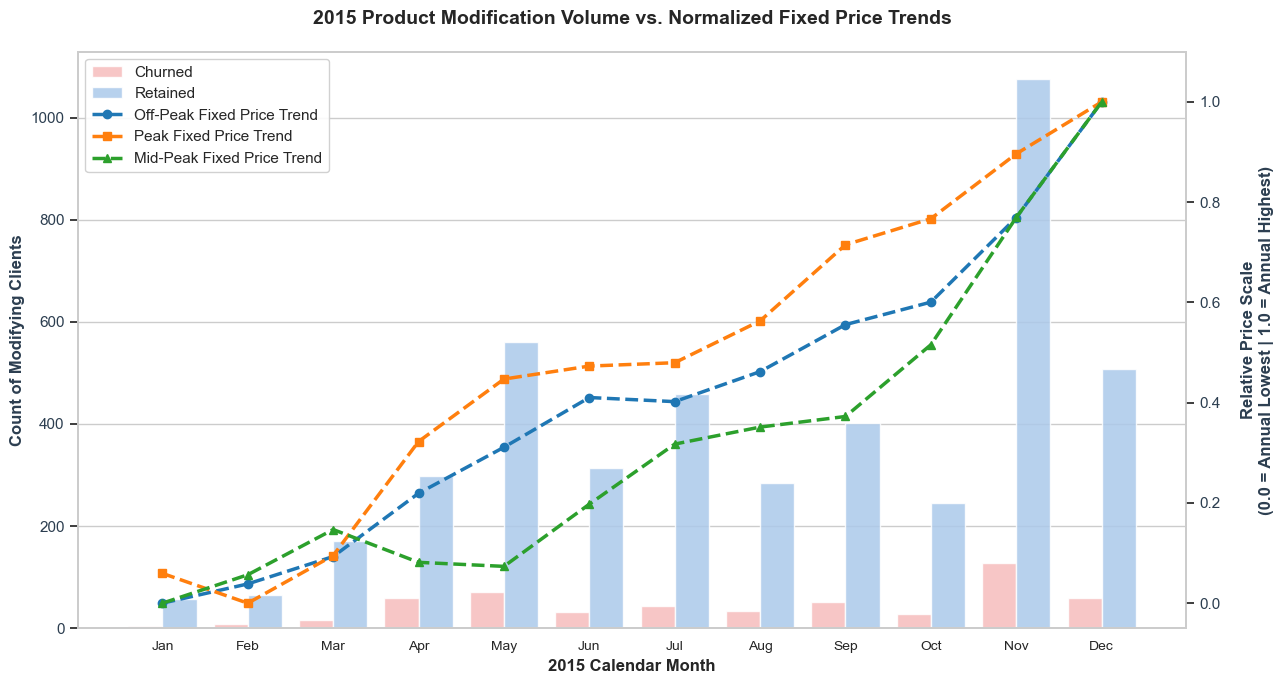

In [28]:
df_2015_clients['date_modif_prod'] = pd.to_datetime(df_2015_clients['date_modif_prod'])
df_2015_clients['month_modif'] = df_2015_clients['date_modif_prod'].dt.month
df_2015_clients['Status'] = df_2015_clients['churn'].map({0: 'Retained', 1: 'Churned'})

# Create a uniform monthly index (1 to 12) for counting modifications
monthly_counts = (
    df_2015_clients.groupby(['month_modif', 'Status'])
    .size()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)

# =====================================================================
# STEP 2: Process and Normalize the Fixed Price Trend Data (Line Data)
# =====================================================================
# Isolate the fixed power price columns this time
fix_cols = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
df_fix_only = df_price[['id', 'price_date'] + fix_cols].copy()

# Exclude 0 values to protect baseline averages
for col in fix_cols:
    df_fix_only[col] = df_fix_only[col].replace(0, float('nan'))

# Group by billing date and sort
monthly_fix_averages = df_fix_only.groupby('price_date')[fix_cols].mean().reset_index()
monthly_fix_averages = monthly_fix_averages.sort_values('price_date')

# Map the price rows to matching months (1 to 12) to align with our bars
monthly_fix_averages['price_date'] = pd.to_datetime(monthly_fix_averages['price_date'])
monthly_fix_averages['Month_Num'] = monthly_fix_averages['price_date'].dt.month

# Apply Min-Max Normalization to force the unit scales into a 0.0 to 1.0 box
monthly_fix_normalized = monthly_fix_averages.copy()
for col in fix_cols:
    col_min = monthly_fix_averages[col].min()
    col_max = monthly_fix_averages[col].max()
    if col_max != col_min:
        monthly_fix_normalized[col] = (monthly_fix_averages[col] - col_min) / (col_max - col_min)
    else:
        monthly_fix_normalized[col] = 0.0

# Ensure the price trends are grouped and indexed exactly 1 to 12
monthly_fix_normalized = monthly_fix_normalized.set_index('Month_Num').reindex(range(1, 13))

# =====================================================================
# STEP 3: Build the Dual-Axis Combined Plot
# =====================================================================
fig, ax1 = plt.subplots(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# --- Primary Axis (Left Y-Axis): Modification Volume Bars ---
bar_data = monthly_counts.reset_index().melt(id_vars='month_modif', value_name='Count')

sns.barplot(
    data=bar_data,
    x='month_modif',
    y='Count',
    hue='Status',
    palette={'Retained': '#a1c9f4', 'Churned': '#ffb3b3'}, # Muted bars to let lines stand out
    edgecolor='white',
    alpha=0.85,
    ax=ax1
)

ax1.set_ylabel('Count of Modifying Clients', fontsize=12, weight='bold', color='#2c3e50')
ax1.set_xlabel('2015 Calendar Month', fontsize=12, weight='bold')
ax1.tick_params(axis='y', labelcolor='#2c3e50')
ax1.get_legend().remove() 

# --- Secondary Axis (Right Y-Axis): Fixed Price Trend Lines ---
ax2 = ax1.twinx()

# Shift x positions (0 to 11) to center line points perfectly above the bar categories
x_positions = [x for x in range(12)]

ax2.plot(x_positions, monthly_fix_normalized['price_off_peak_fix'], marker='o', linewidth=2.5, color='#1f77b4', linestyle='--', label='Off-Peak Fixed Price Trend')
ax2.plot(x_positions, monthly_fix_normalized['price_peak_fix'], marker='s', linewidth=2.5, color='#ff7f0e', linestyle='--', label='Peak Fixed Price Trend')
ax2.plot(x_positions, monthly_fix_normalized['price_mid_peak_fix'], marker='^', linewidth=2.5, color='#2ca02c', linestyle='--', label='Mid-Peak Fixed Price Trend')

ax2.set_ylabel('Relative Price Scale\n(0.0 = Annual Lowest | 1.0 = Annual Highest)', fontsize=12, weight='bold', color='#2c3e50', labelpad=15)
ax2.tick_params(axis='y', labelcolor='#2c3e50')
ax2.set_ylim(-0.05, 1.1) 
ax2.grid(False) # Clean background accentuation

# --- Formatting Labels & Legend ---
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels, fontsize=10)

# Merge legends cleanly from both coordinate systems
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + labels, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('2015 Product Modification Volume vs. Normalized Fixed Price Trends', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.savefig('combined_modification_and_fixed_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

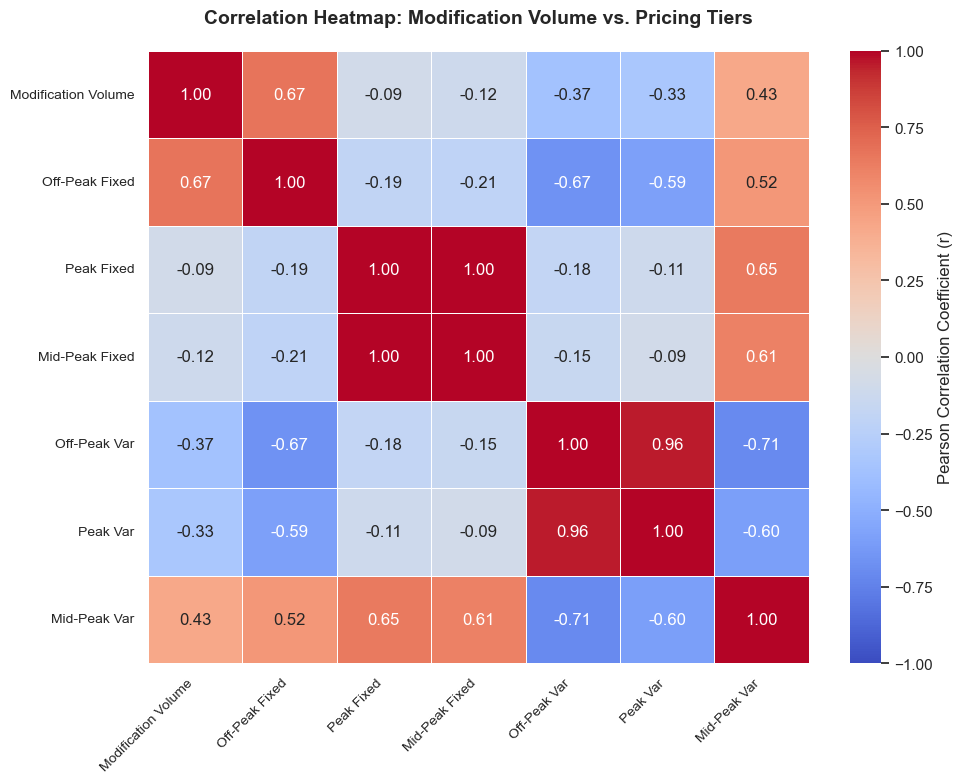

In [34]:


# =====================================================================
# STEP 1: Aggregate Modification Volume per Month
# =====================================================================
# Count how many clients modified their plans each month
mod_counts = df_2015_clients.groupby('month_modif').size().reset_index(name='Modification_Volume')
mod_counts.rename(columns={'month_modif': 'Month'}, inplace=True)

# =====================================================================
# STEP 2: Aggregate Average Prices per Month
# =====================================================================
# Ensure datetime format and extract the month
df_price['price_date'] = pd.to_datetime(df_price['price_date'])
df_price['Month'] = df_price['price_date'].dt.month

# Calculate the average prices for both Fixed and Variable tiers per month
price_cols = [
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix',
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var'
]
monthly_prices = df_price.groupby('Month')[price_cols].mean().reset_index()

# =====================================================================
# STEP 3: Merge and Calculate Correlation
# =====================================================================
# Combine volume and prices into one dataframe mapped by Month
df_monthly = pd.merge(mod_counts, monthly_prices, on='Month', how='inner')

# Drop the 'Month' column so it doesn't skew our math, then calculate the correlation matrix
df_corr_data = df_monthly.drop(columns=['Month'])
corr_matrix = df_corr_data.corr()

# =====================================================================
# STEP 4: Render the Correlation Heatmap
# =====================================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Plot using a diverging colormap (Blue = Negative Corr, Red = Positive Corr)
ax = sns.heatmap(
    corr_matrix, 
    annot=True,              # Prints the exact correlation decimal inside the box
    fmt=".2f",               # Rounds to 2 decimal places
    cmap="coolwarm",         # Diverging color map 
    vmin=-1, vmax=1,         # Forces the scale to perfectly span -1.0 to 1.0
    linewidths=.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

# --- Formatting ---
plt.title('Correlation Heatmap: Modification Volume vs. Pricing Tiers', fontsize=14, pad=20, weight='bold')

# Clean up axis labels to make them readable
clean_labels = ['Modification Volume', 'Off-Peak Fixed', 'Peak Fixed', 'Mid-Peak Fixed', 'Off-Peak Var', 'Peak Var', 'Mid-Peak Var']
ax.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(clean_labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

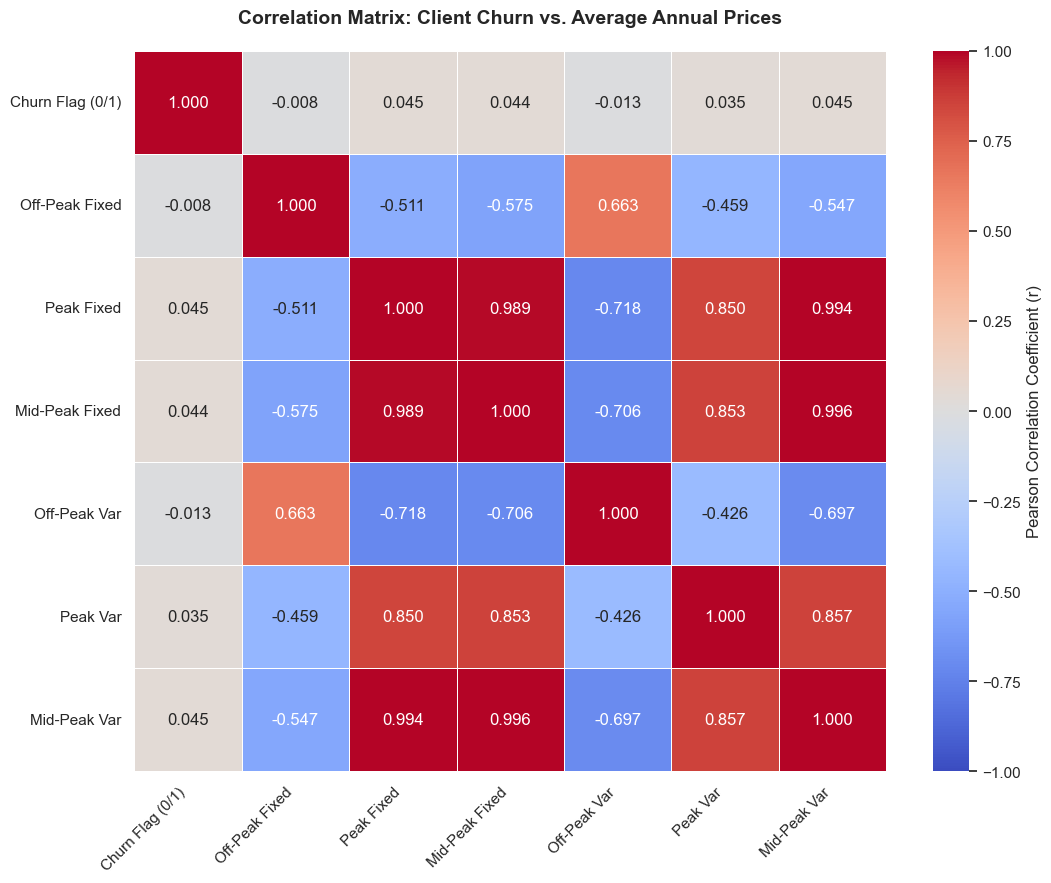

In [35]:


# =====================================================================
# STEP 1: Encode Churn & Calculate Average Prices per Client
# =====================================================================
# 1. Isolate the churn data and ensure it is encoded as a numeric integer (0 = Retained, 1 = Churned)
df_churn_encoded = df_2015_clients[['id', 'churn']].copy()
df_churn_encoded['churn'] = df_churn_encoded['churn'].astype(int)

# 2. Calculate the average price across the entire year for EACH individual client
price_cols = [
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix',
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var'
]
client_avg_prices = df_price.groupby('id')[price_cols].mean().reset_index()

# =====================================================================
# STEP 2: Merge and Calculate the Correlation Matrix
# =====================================================================
# Combine the 0/1 churn flag with the client's average prices
df_client_corr = pd.merge(df_churn_encoded, client_avg_prices, on='id', how='inner')

# Drop the 'id' column because ID strings/hashes cannot be correlated mathematically
df_client_corr = df_client_corr.drop(columns=['id'])

# Calculate the Pearson Correlation Matrix
corr_matrix = df_client_corr.corr()

# =====================================================================
# STEP 3: Render the Heatmap
# =====================================================================
plt.figure(figsize=(11, 9))
sns.set_theme(style="white")

# Plot using a diverging colormap (Blue = Negative, Red = Positive)
ax = sns.heatmap(
    corr_matrix, 
    annot=True,              # Prints the exact correlation decimal inside the box
    fmt=".3f",               # 3 decimal places are needed because individual correlations might be small
    cmap="coolwarm",         
    vmin=-1, vmax=1,         # Forces the scale to perfectly span -1.0 to 1.0
    linewidths=.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

# --- Formatting ---
plt.title('Correlation Matrix: Client Churn vs. Average Annual Prices', fontsize=14, pad=20, weight='bold')

# Clean up axis labels 
clean_labels = ['Churn Flag (0/1)', 'Off-Peak Fixed', 'Peak Fixed', 'Mid-Peak Fixed', 'Off-Peak Var', 'Peak Var', 'Mid-Peak Var']
ax.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(clean_labels, rotation=0, fontsize=11)

# Highlight the Churn row/column visually by adding a slight box or just letting the user focus on it
plt.tight_layout()
plt.show()

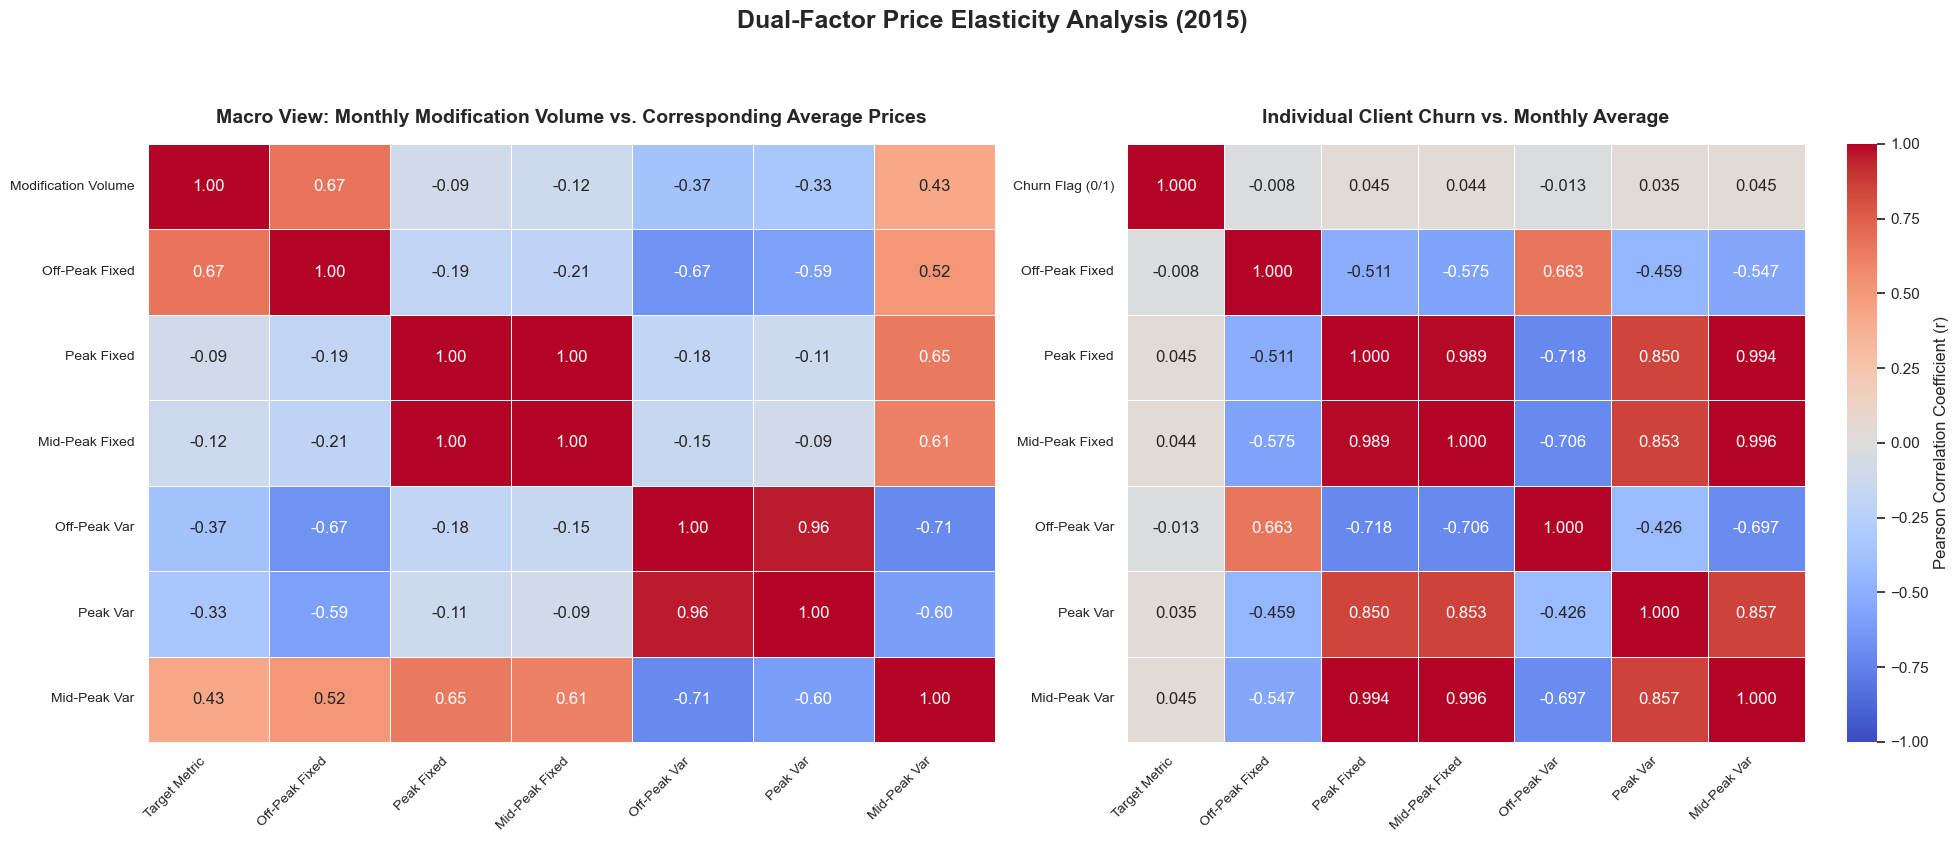

In [37]:

# =====================================================================
# DATA PREP 1: Monthly Modification Volume vs. Prices
# =====================================================================
df_price['price_date'] = pd.to_datetime(df_price['price_date'])
df_price['Month'] = df_price['price_date'].dt.month

price_cols = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix',
              'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']

# Aggregate volume and prices by month
mod_counts = df_2015_clients.groupby('month_modif').size().reset_index(name='Modification_Volume')
mod_counts.rename(columns={'month_modif': 'Month'}, inplace=True)
monthly_prices = df_price.groupby('Month')[price_cols].mean().reset_index()

# Merge and calculate matrix 1
df_monthly = pd.merge(mod_counts, monthly_prices, on='Month', how='inner')
corr_matrix_monthly = df_monthly.drop(columns=['Month']).corr()

# =====================================================================
# DATA PREP 2: Client Churn vs. Average Annual Prices
# =====================================================================
# Encode churn and calculate average annual prices per client
df_churn_encoded = df_2015_clients[['id', 'churn']].copy()
df_churn_encoded['churn'] = df_churn_encoded['churn'].astype(int)
client_avg_prices = df_price.groupby('id')[price_cols].mean().reset_index()

# Merge and calculate matrix 2
df_client_corr = pd.merge(df_churn_encoded, client_avg_prices, on='id', how='inner')
corr_matrix_client = df_client_corr.drop(columns=['id']).corr()

# =====================================================================
# PLOTTING: 1x2 Dashboard Layout
# =====================================================================
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="white")

clean_labels = ['Target Metric', 'Off-Peak Fixed', 'Peak Fixed', 'Mid-Peak Fixed', 
                'Off-Peak Var', 'Peak Var', 'Mid-Peak Var']

# --- Left Subplot (ax1): Monthly Volume Correlation ---
sns.heatmap(
    corr_matrix_monthly, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
    linewidths=.5, cbar=False, # Turn off colorbar here to avoid clutter
    ax=ax1 # Directs this heatmap to the left subplot
)
ax1.set_title('Macro View: Monthly Modification Volume vs. Corresponding Average Prices', fontsize=14, pad=15, weight='bold')
ax1.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=10)
ax1.set_yticklabels(['Modification Volume'] + clean_labels[1:], rotation=0, fontsize=10)

# --- Right Subplot (ax2): Client Churn Correlation ---
sns.heatmap(
    corr_matrix_client, 
    annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, 
    linewidths=.5, 
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'},
    ax=ax2 # Directs this heatmap to the right subplot
)
ax2.set_title('Individual Client Churn vs. Monthly Average', fontsize=14, pad=15, weight='bold')
ax2.set_xticklabels(clean_labels, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(['Churn Flag (0/1)'] + clean_labels[1:], rotation=0, fontsize=10)

# --- Final Presentation Adjustments ---
plt.suptitle('Dual-Factor Price Elasticity Analysis (2015)', fontsize=18, weight='bold', y=1.05)
plt.tight_layout()
plt.savefig('combined_correlation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
print("--- CHURN PERCENTAGES BY CATEGORY ---\n")

# ------------------------------------------------------------------
# CATEGORY 1: Sales Channel (channel_sales)
# ------------------------------------------------------------------
print("1. Churn Rate by Sales Channel:")
# Calculate row-wise percentages
channel_churn = pd.crosstab(df_client['channel_sales'], df_client['churn'], normalize='index') * 100
# Rename columns for clear display
channel_churn.columns = ['Retained_ %', 'Churned_%']
print(channel_churn.round(2))
print("\n" + "="*50 + "\n")

# ------------------------------------------------------------------
# CATEGORY 2: Number of Active Products (nb_prod_act)
# ------------------------------------------------------------------
print("2. Churn Rate by Number of Active Products:")
product_churn = pd.crosstab(df_client['nb_prod_act'], df_client['churn'], normalize='index') * 100
product_churn.columns = ['Retained_ %', 'Churned_%']
print(product_churn.round(2))
print("\n" + "="*50 + "\n")

# ------------------------------------------------------------------
# CATEGORY 3: Customer Tenure / Years (num_years_antig)
# ------------------------------------------------------------------
print("3. Churn Rate by Customer Tenure (Years):")
tenure_churn = pd.crosstab(df_client['num_years_antig'], df_client['churn'], normalize='index') * 100
tenure_churn.columns = ['Retained_ %', 'Churned_%']
print(tenure_churn.round(2))

--- CHURN PERCENTAGES BY CATEGORY ---

1. Churn Rate by Sales Channel:
                                  Retained_ %  Churned_%
channel_sales                                           
MISSING                                 92.40       7.60
epumfxlbckeskwekxbiuasklxalciiuu       100.00       0.00
ewpakwlliwisiwduibdlfmalxowmwpci        91.60       8.40
fixdbufsefwooaasfcxdxadsiekoceaa       100.00       0.00
foosdfpfkusacimwkcsosbicdxkicaua        87.86      12.14
lmkebamcaaclubfxadlmueccxoimlema        94.41       5.59
sddiedcslfslkckwlfkdpoeeailfpeds       100.00       0.00
usilxuppasemubllopkaafesmlibmsdf        89.96      10.04


2. Churn Rate by Number of Active Products:
             Retained_ %  Churned_%
nb_prod_act                        
1                  90.02       9.98
2                  91.49       8.51
3                  90.06       9.94
4                  90.00      10.00
5                  90.32       9.68
6                 100.00       0.00
8                 100.00 

In [13]:
# 1. Create the new column by automatically converting the hashes to sequential numbers
df_client['new_condition'] = df_client['channel_sales'].astype('category').cat.codes.map(lambda x: f"channel {x+1}")

# 2. Delete the old messy column permanently
df_client.drop(columns=['channel_sales'], inplace=True)

# 3. Print your clean results to verify it worked perfectly
print("--- New Column Categories Created ---")
print(df_client['new_condition'].value_counts())

--- New Column Categories Created ---
new_condition
channel 5    6754
channel 1    3725
channel 6    1843
channel 8    1375
channel 3     893
channel 7      11
channel 2       3
channel 4       2
Name: count, dtype: int64


C:\Users\yuqin\AppData\Local\Temp\ipykernel_30796\64226479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_channels.index, y=sorted_channels.values, palette="Blues_r")


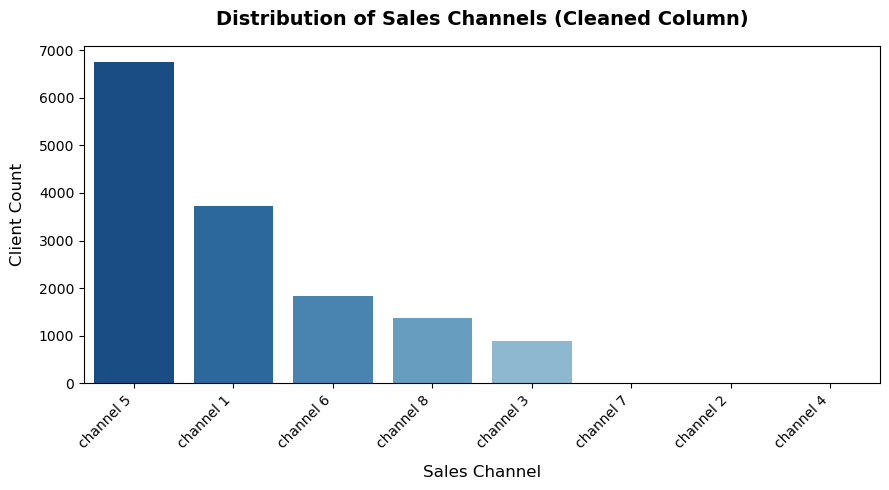

In [14]:


# 1. Compute value counts and ensure they are sorted from highest to lowest frequency
sorted_channels = df_client['new_condition'].value_counts()

# 2. Set style and generate the bar chart layout
plt.figure(figsize=(9, 5))
sns.barplot(x=sorted_channels.index, y=sorted_channels.values, palette="Blues_r")

# 3. Add professional labels, titles, and clean padding
plt.title("Distribution of Sales Channels (Cleaned Column)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sales Channel", fontsize=12, labelpad=10)
plt.ylabel("Client Count", fontsize=12, labelpad=10)

# 4. Rotate labels to prevent truncation or overlapping text
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 5. Display the final visualization
plt.show()

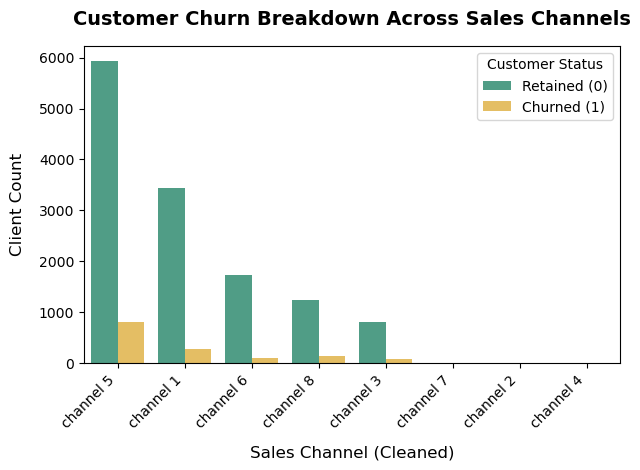

In [19]:

# Green tint for Retained (0), Orange/Coral tint for Churned (1)
custom_colors = ["#43aa8b", "#f9c74f"] 

# 6. Plot the counts of each channel segmented by churn status
sns.countplot(
    data=df_client, 
    x='new_condition', 
    hue='churn', 
    order=channel_order,
    palette=custom_colors
)

# 7. Add clear titles, labels, and customize the legend layers
plt.title("Customer Churn Breakdown Across Sales Channels", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sales Channel (Cleaned)", fontsize=12, labelpad=10)
plt.ylabel("Client Count", fontsize=12, labelpad=10)
plt.legend(title="Customer Status", labels=["Retained (0)", "Churned (1)"], loc="upper right")

# 8. Rotate the x-axis identifiers to ensure non-overlapping, readable labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 9. Render the visualization layout
plt.savefig("chanel_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
churn_profile = pd.crosstab(df_client['new_condition'], df_client['churn'], normalize='index') * 100

# 2. Rename columns cleanly for presentation (adjust if your column has True/False or Yes/No)
churn_profile.columns = ['Retained %', 'Churned %']

# 3. Sort by the highest churn rate to easily identify risky channels
churn_profile = churn_profile.sort_values(by='Churned %', ascending=False)

# 4. Display the results
print("--- Churn Percentage Breakdown By Channel ---")
print(churn_profile.round(2))

--- Churn Percentage Breakdown By Channel ---
               Retained %  Churned %
new_condition                       
channel 5           87.86      12.14
channel 8           89.96      10.04
channel 3           91.60       8.40
channel 1           92.40       7.60
channel 6           94.41       5.59
channel 2          100.00       0.00
channel 4          100.00       0.00
channel 7          100.00       0.00


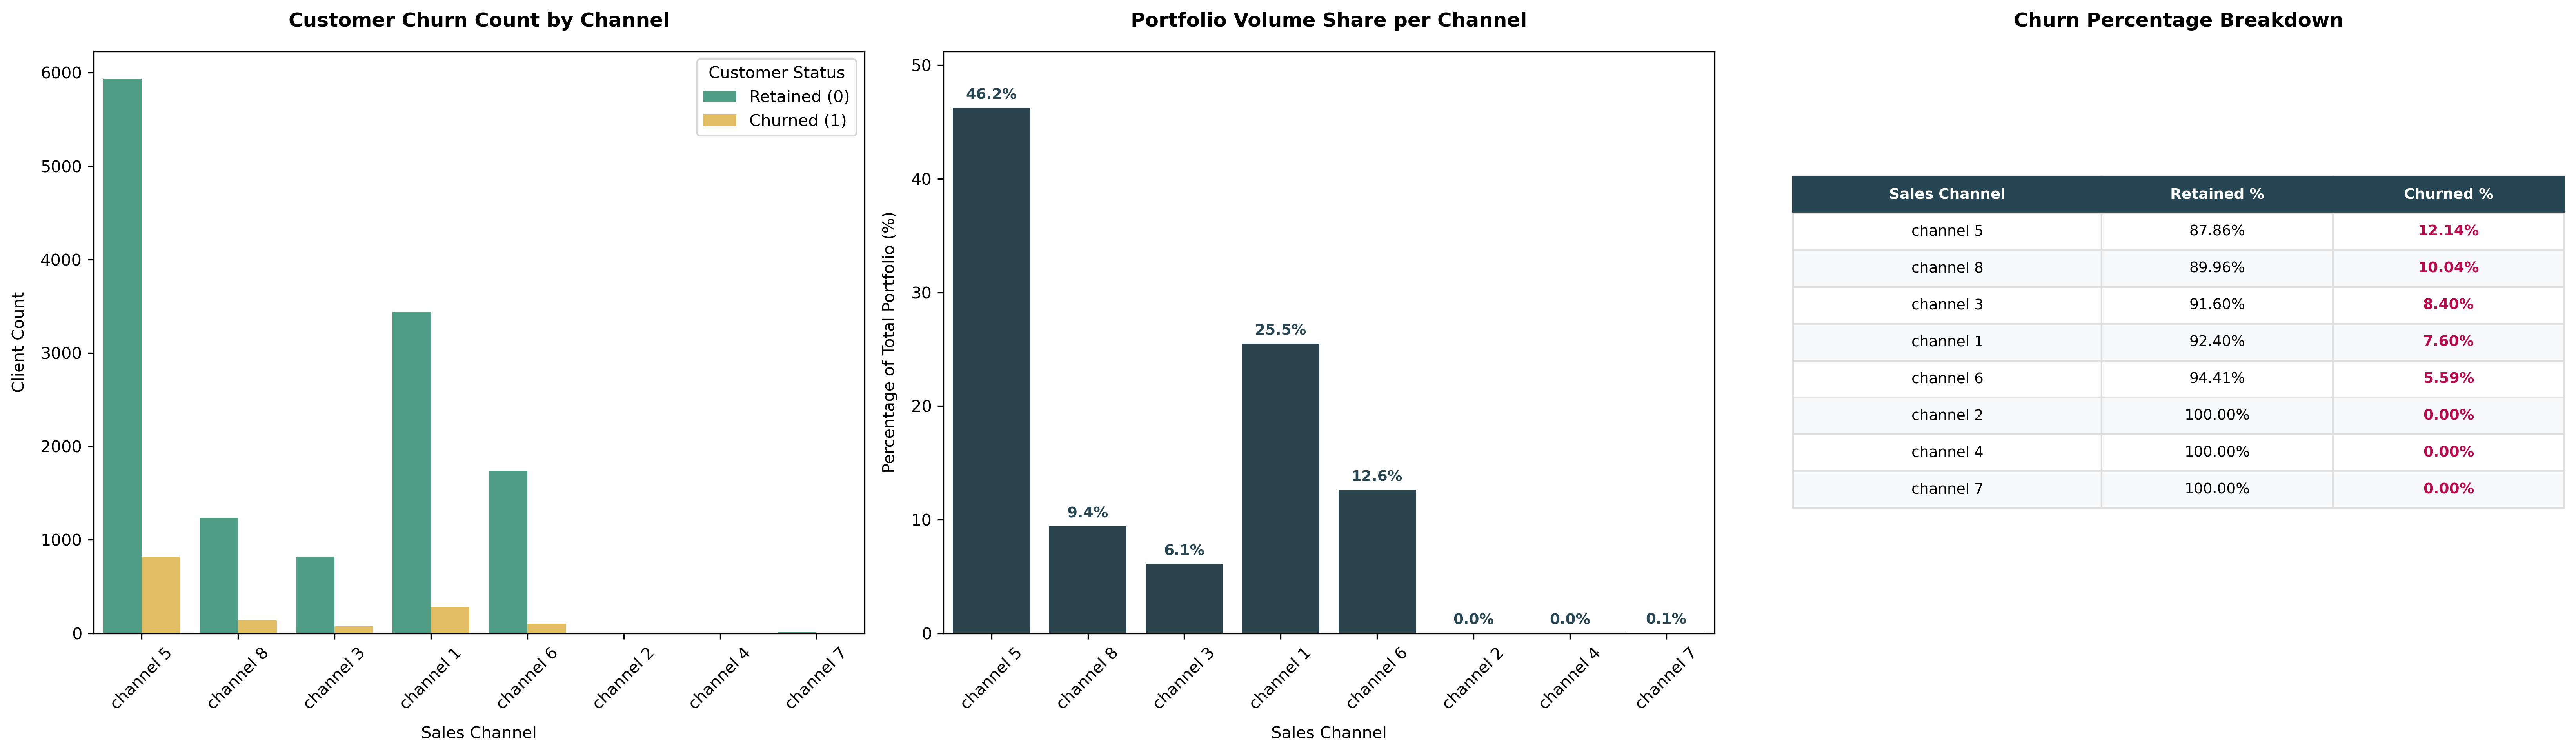

In [22]:
churn_profile = pd.crosstab(df_client['new_condition'], df_client['churn'], normalize='index') * 100
churn_profile.columns = ['Retained %', 'Churned %']
churn_profile = churn_profile.sort_values(by='Churned %', ascending=False)

# Force the volume distribution list to follow the exact same descending channel order
channel_order = churn_profile.index
channel_volume_pct = df_client['new_condition'].value_counts(normalize=True) * 100
channel_volume_pct = channel_volume_pct.reindex(channel_order)

# 2. INITIALIZE A 1x3 SUBPLOT CANVAS (1 Row, 3 Columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6.5), dpi=300)
custom_colors = ["#43aa8b", "#f9c74f"]  # Green for Retained (0), Orange for Churned (1)
theme_navy = '#264653'

# =====================================================================
# AX1 (LEFT): CHURN COUNT SEGMENTATION
# =====================================================================
sns.countplot(
    data=df_client, 
    x='new_condition', 
    hue='churn', 
    order=channel_order,
    palette=custom_colors,
    ax=ax1
)
ax1.set_title("Customer Churn Count by Channel", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Sales Channel", fontsize=10, labelpad=8)
ax1.set_ylabel("Client Count", fontsize=10, labelpad=8)
ax1.legend(title="Customer Status", labels=["Retained (0)", "Churned (1)"], loc="upper right")
ax1.tick_params(axis='x', rotation=45)

# =====================================================================
# AX2 (CENTER): VOLUME DISTRIBUTION (%)
# =====================================================================
sns.barplot(
    x=channel_volume_pct.index, 
    y=channel_volume_pct.values, 
    color=theme_navy, 
    ax=ax2
)
ax2.set_title("Portfolio Volume Share per Channel", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("Sales Channel", fontsize=10, labelpad=8)
ax2.set_ylabel("Percentage of Total Portfolio (%)", fontsize=10, labelpad=8)
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, max(channel_volume_pct.values) + 5)

# Append raw text percentages on top of the bars
for i, val in enumerate(channel_volume_pct.values):
    ax2.text(i, val + 0.5, f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold', color=theme_navy)

# =====================================================================
# AX3 (RIGHT): STYLED METRICS SUMMARY TABLE
# =====================================================================
ax3.axis('off')  # Strip out grid layout blocks

cell_text = []
for channel_name, row in churn_profile.iterrows():
    cell_text.append([channel_name, f"{row['Retained %']:.2f}%", f"{row['Churned %']:.2f}%"])

column_headers = ['Sales Channel', 'Retained %', 'Churned %']

data_table = ax3.table(
    cellText=cell_text, 
    colLabels=column_headers, 
    cellLoc='center', 
    loc='center',
    colWidths=[0.4, 0.3, 0.3]
)

data_table.auto_set_font_size(False)
data_table.set_fontsize(9)
data_table.scale(1.0, 1.9)  # Adds clean row padding inside the grid

# Apply zebra striping and custom colored header values
row_even_bg = '#f8f9fa'
row_odd_bg = '#ffffff'

for cell_coordinates, cell_element in data_table.get_celld().items():
    row_idx, col_idx = cell_coordinates
    if row_idx == 0:
        cell_element.set_text_props(color='white', weight='bold')
        cell_element.set_facecolor(theme_navy)
        cell_element.set_edgecolor(theme_navy)
    else:
        cell_element.set_facecolor(row_even_bg if row_idx % 2 == 0 else row_odd_bg)
        cell_element.set_edgecolor('#e0e0e0')
        if col_idx == 2:
            cell_element.set_text_props(weight='bold', color='#b7094c')

ax3.set_title("Churn Percentage Breakdown", fontsize=12, fontweight='bold', pad=15)

# =====================================================================
# RENDER AND EXPORT DASHBOARD
# =====================================================================
plt.tight_layout()
plt.savefig("channel_performance_1x3_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

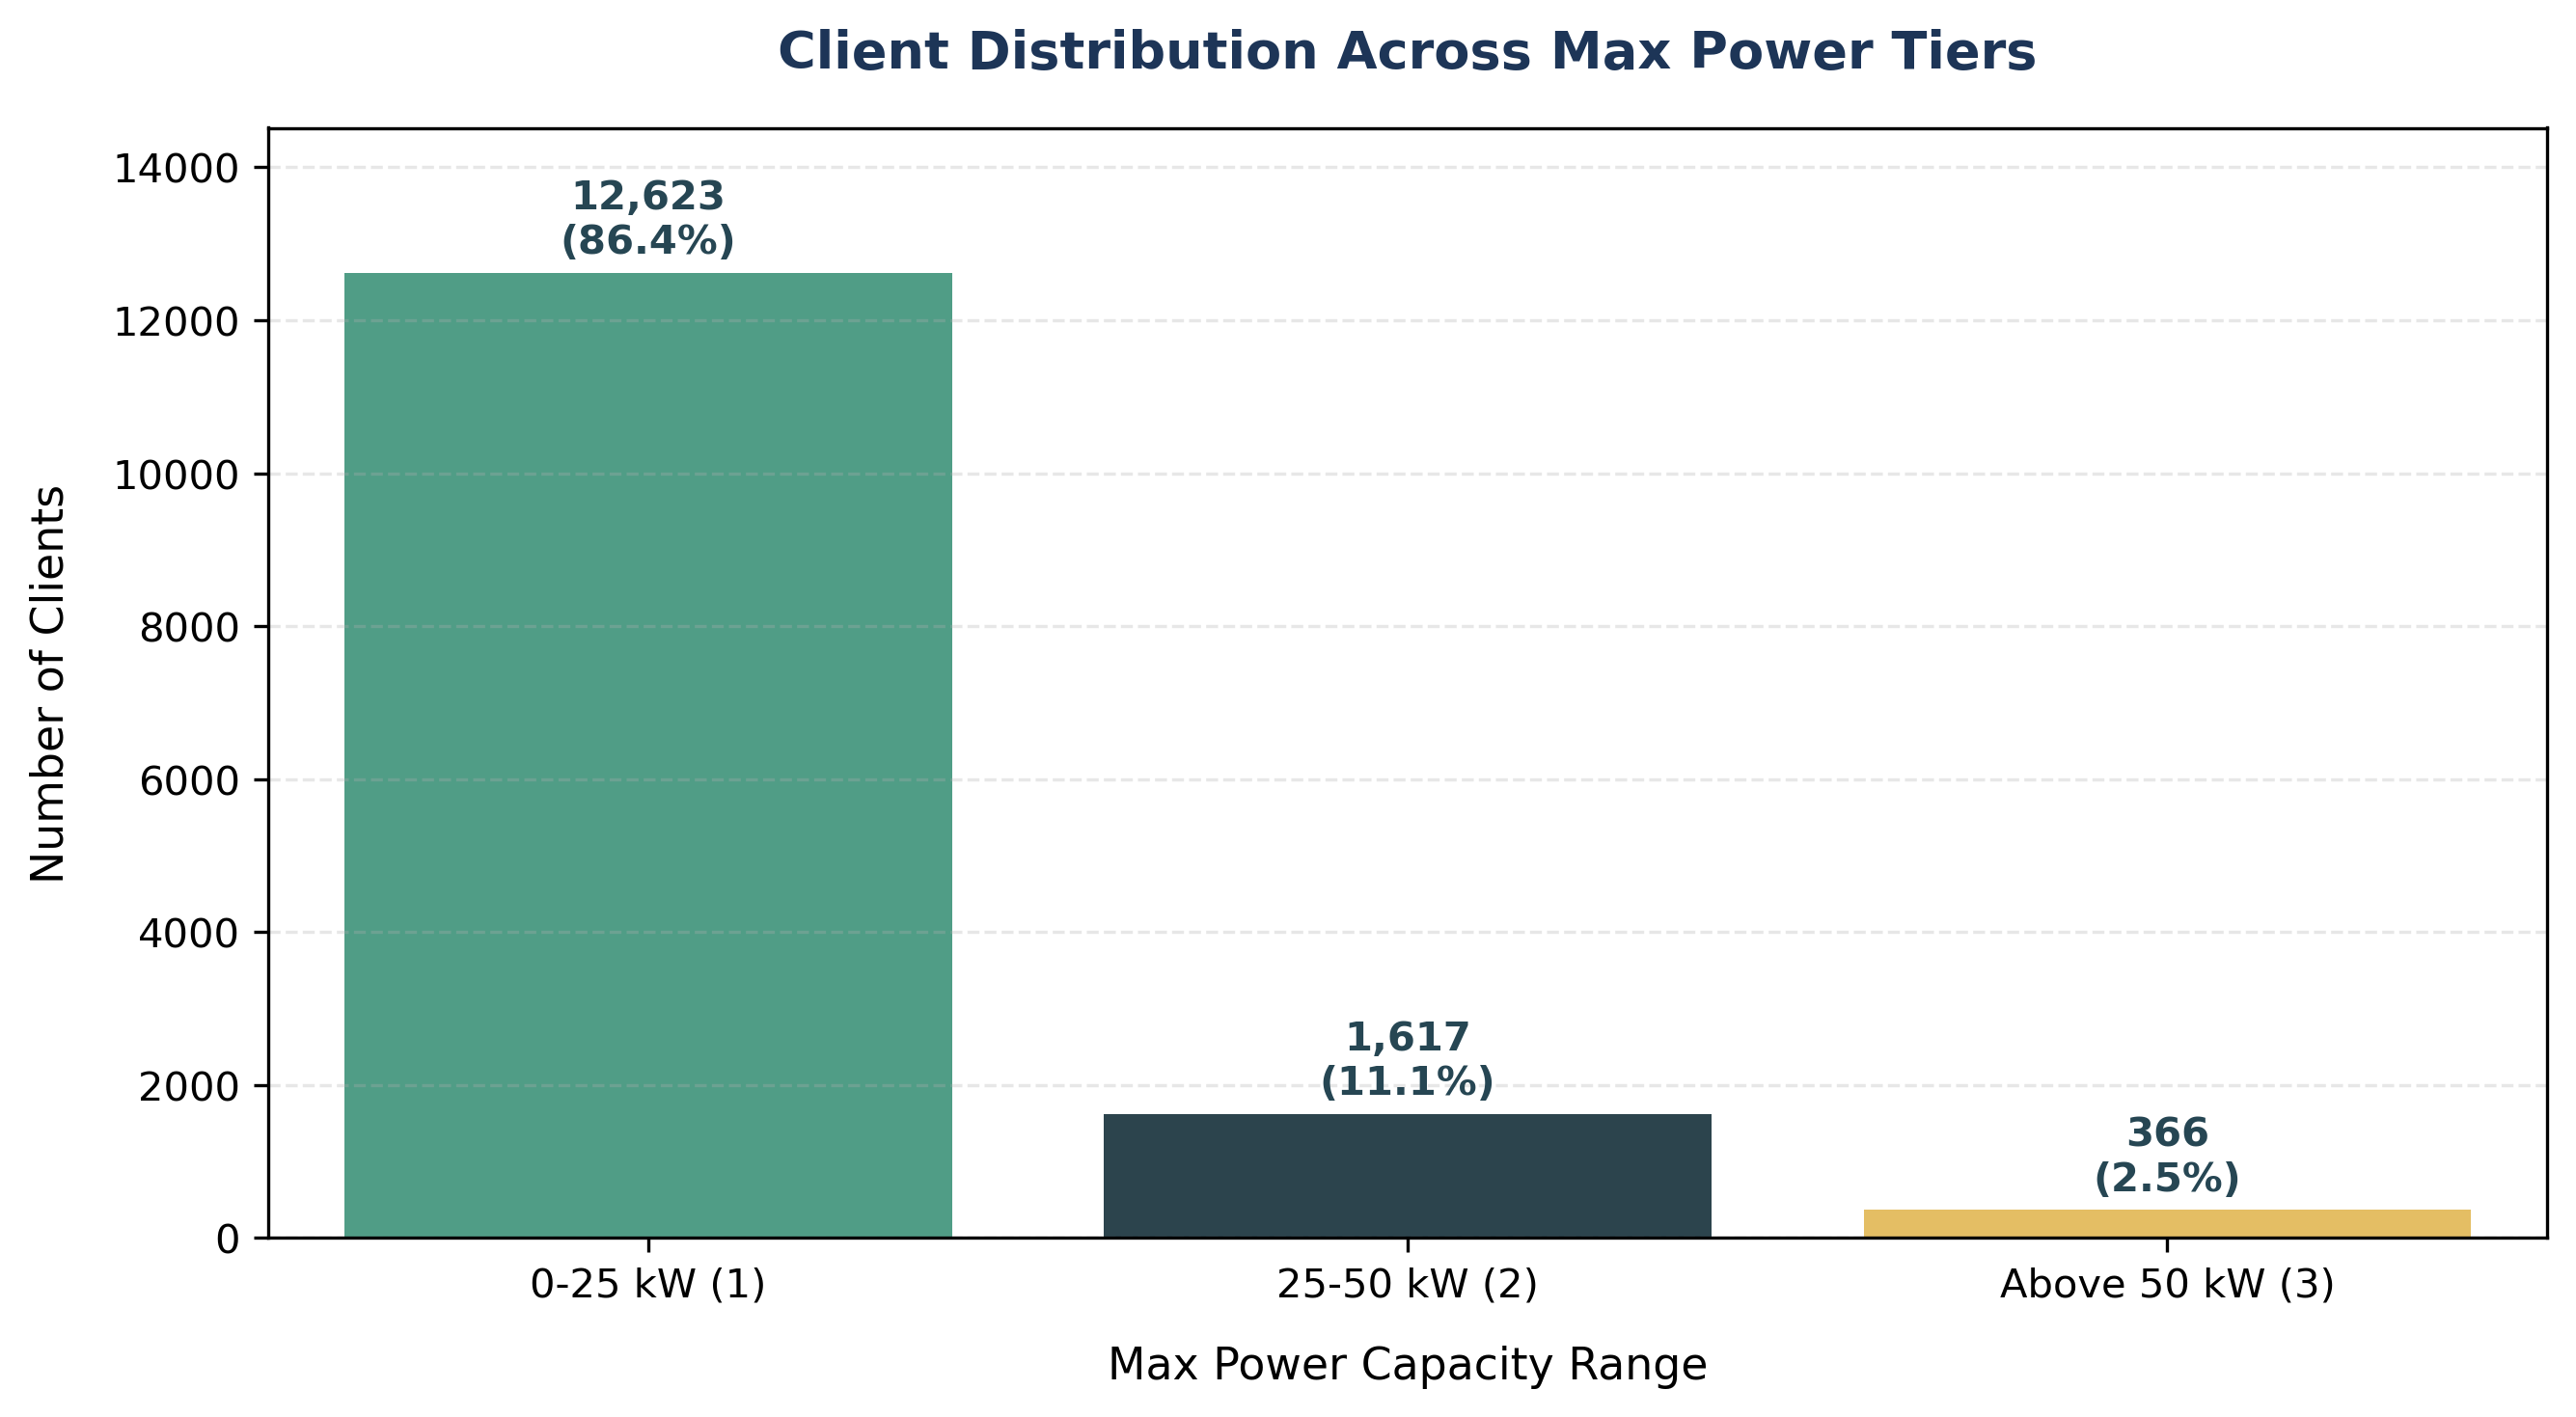

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Categorize the max power values into your 3 specific bins
bin_edges = [0, 25, 50, np.inf]
bin_labels = ['0-25 kW (1)', '25-50 kW (2)', 'Above 50 kW (3)']

df_client['power_bin'] = pd.cut(
    df_client['pow_max'], 
    bins=bin_edges, 
    labels=bin_labels
)

# 2. Set up the figure canvas
plt.figure(figsize=(9, 5), dpi=300)

# 3. Apply your custom color theme
custom_colors = ["#43aa8b", "#264653", "#f9c74f"]

# 4. Plot the histogram distribution of the 3 power tiers
ax = sns.countplot(
    data=df_client,
    x='power_bin',
    palette=custom_colors,
    hue='power_bin',  # Assigns colors per bin cleanly
    legend=False
)

# 5. Calculate and display exact client counts and portfolio percentages on top of each bar
total_clients = len(df_client)
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:  # Ensure text is only added if data exists
        percentage = (height / total_clients) * 100
        ax.text(
            patch.get_x() + patch.get_width() / 2.0, 
            height + (total_clients * 0.01),  # Dynamic padding above the bar
            f"{int(height):,}\n({percentage:.1f}%)", 
            ha='center', 
            va='bottom', 
            fontsize=10, 
            fontweight='bold', 
            color='#264653'
        )

# 6. Customize headers, labels, and gridlines
plt.title("Client Distribution Across Max Power Tiers", fontsize=13, fontweight='bold', pad=15, color='#1d3557')
plt.xlabel("Max Power Capacity Range", fontsize=11, labelpad=10)
plt.ylabel("Number of Clients", fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Expand the upper y-limit slightly to leave room for the text labels
ax.set_ylim(0, df_client['power_bin'].value_counts().max() * 1.15)

# 7. Save the plot to your workspace
plt.tight_layout()
plt.savefig("power_max_3_bins_distribution.png", dpi=300, bbox_inches='tight')

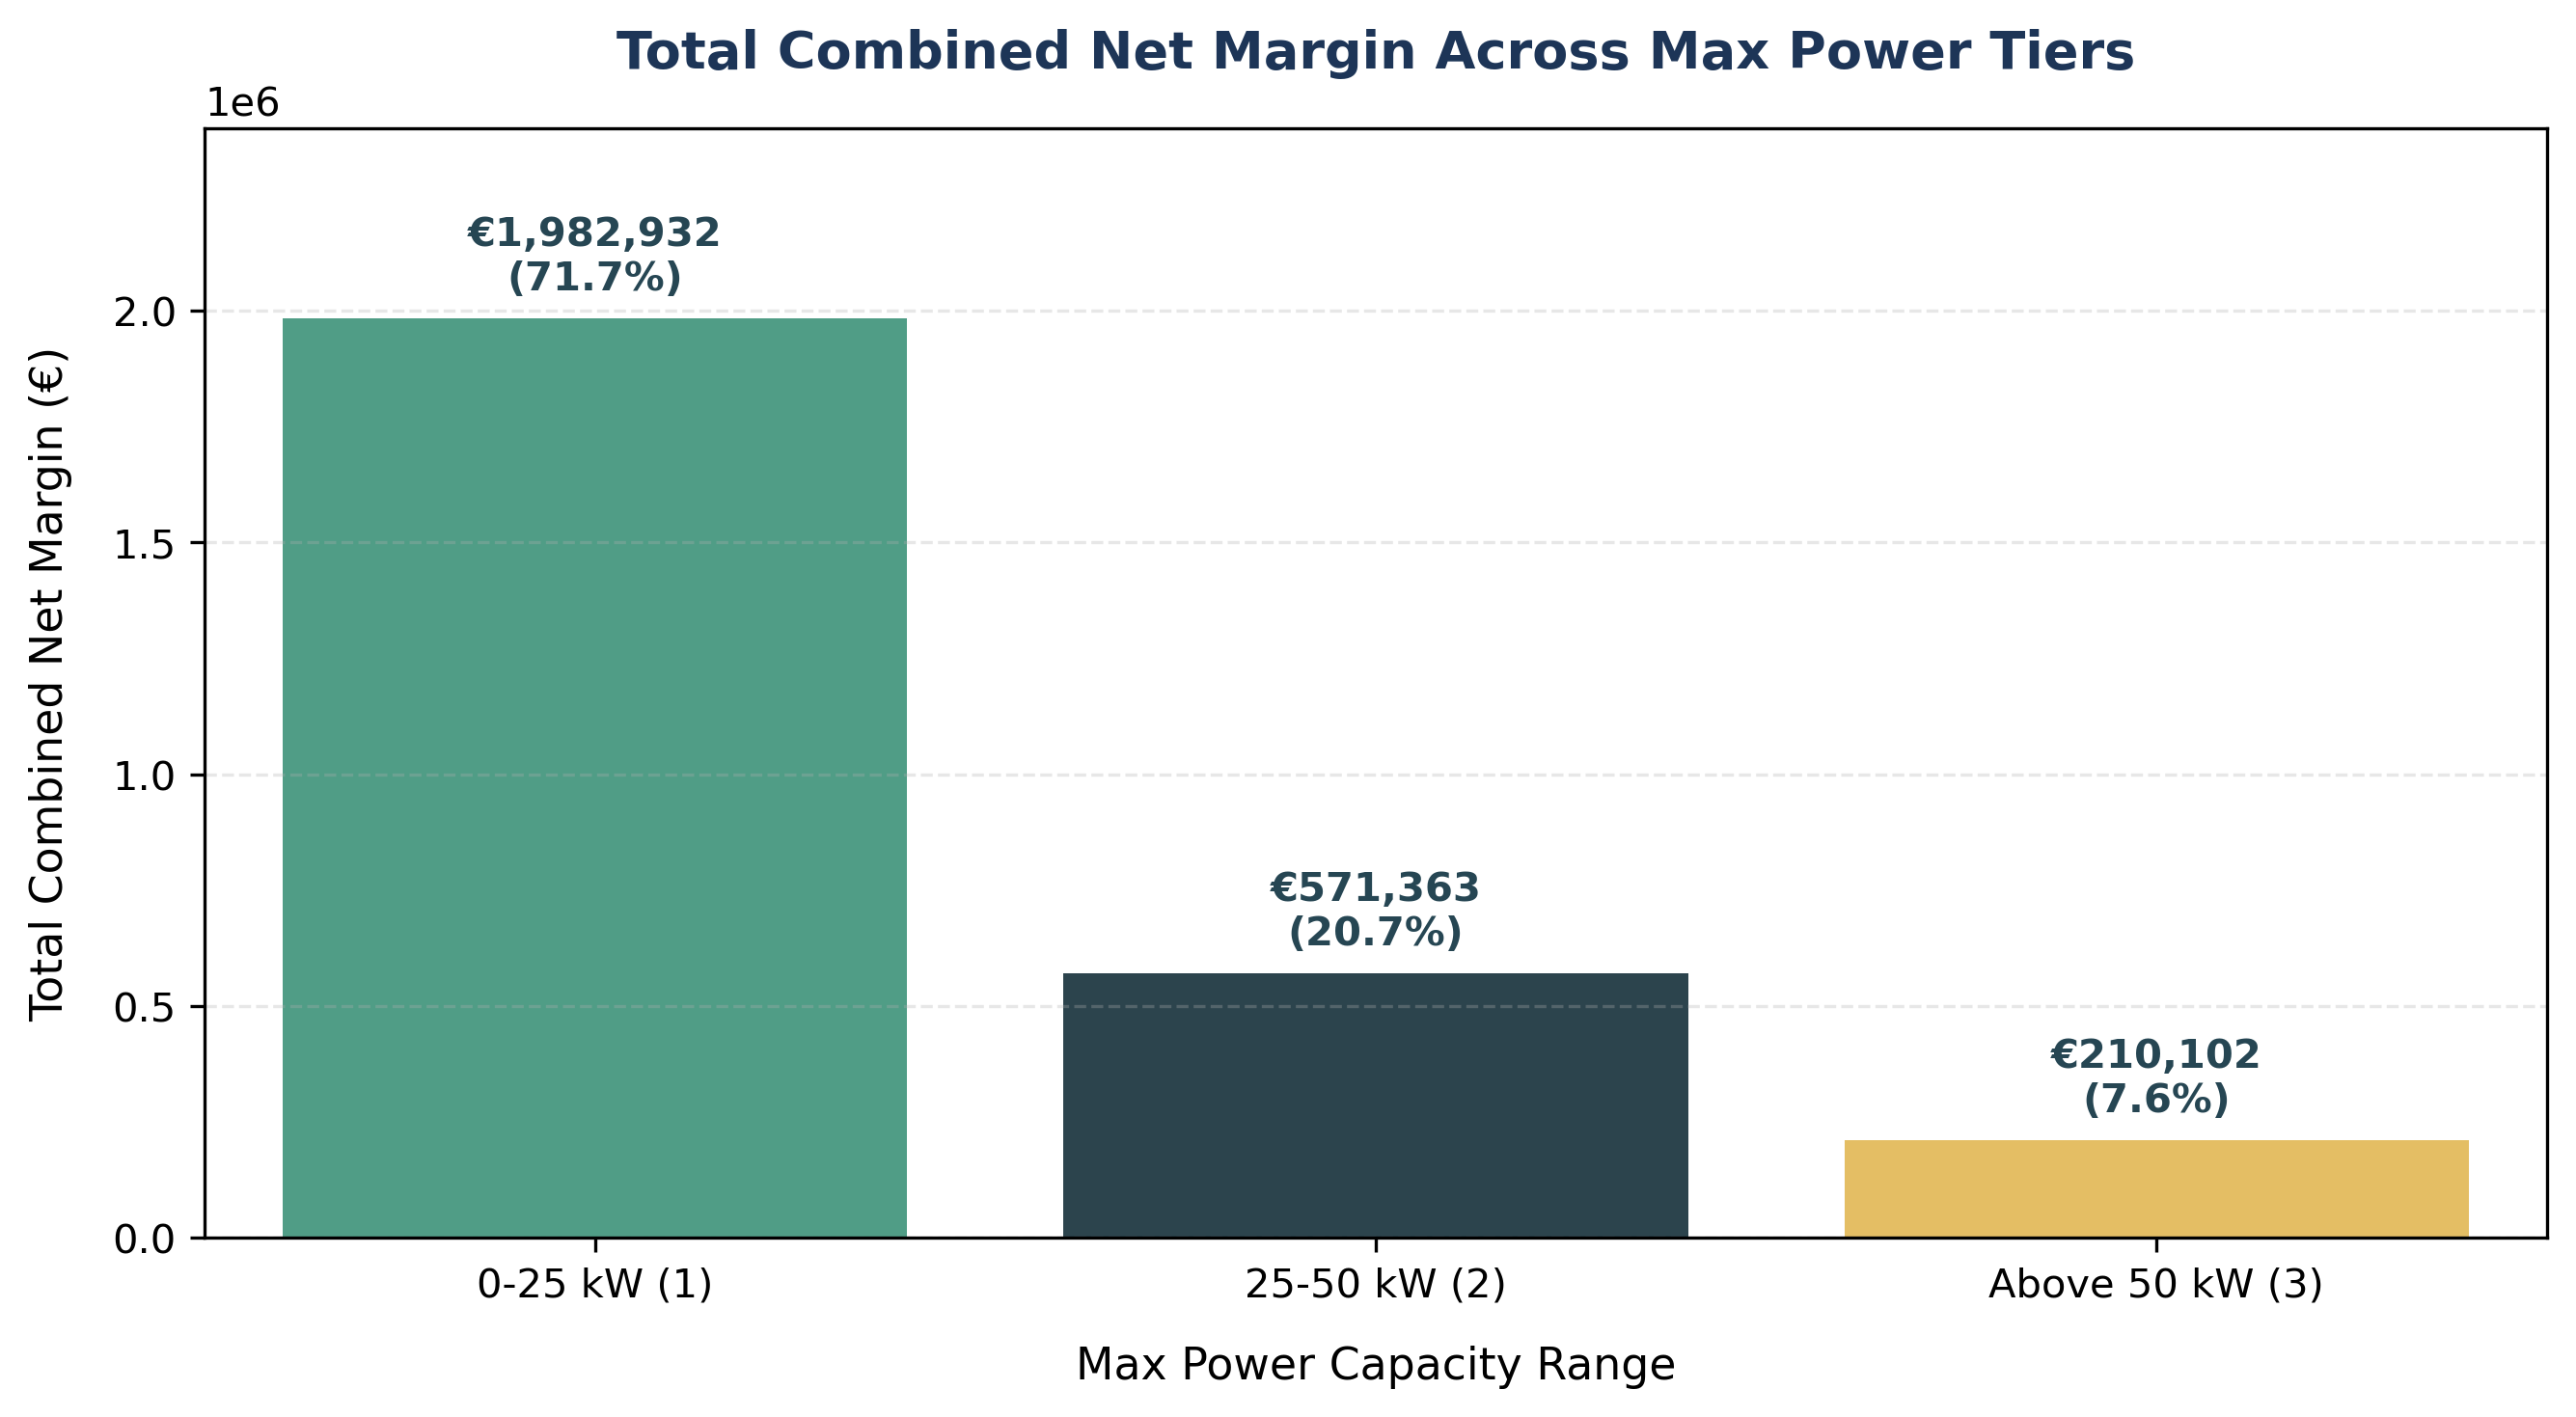

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Categorize the max power values into your 3 specific bins
bin_edges = [0, 25, 50, np.inf]
bin_labels = ['0-25 kW (1)', '25-50 kW (2)', 'Above 50 kW (3)']

df_client['power_bin'] = pd.cut(
    df_client['pow_max'], 
    bins=bin_edges, 
    labels=bin_labels
)

# 2. Calculate the combined (total sum) net margin generated by each power tier
combined_margin = df_client.groupby('power_bin', observed=False)['net_margin'].sum().reset_index()

# 3. Set up the figure canvas layout using subplots
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# 4. Apply your corporate color theme
custom_colors = ["#43aa8b", "#264653", "#f9c74f"]

# 5. Plot the total combined net margin per power tier
sns.barplot(
    data=combined_margin,
    x='power_bin',
    y='net_margin',
    palette=custom_colors,
    hue='power_bin',
    legend=False,
    ax=ax
)

# 6. Calculate the total overall portfolio margin to compute percentage contributions
total_portfolio_margin = combined_margin['net_margin'].sum()

# Add exact euro value labels and portfolio shares on top of each bar
for patch in ax.patches:
    height = patch.get_height()
    
    # Adjust alignment and text offset to cleanly handle both positive and negative margins
    va_direction = 'bottom' if height >= 0 else 'top'
    text_offset = (0, 5) if height >= 0 else (0, -15)
    
    percentage = (height / total_portfolio_margin) * 100 if total_portfolio_margin != 0 else 0
    
    ax.annotate(
        f"€{height:,.0f}\n({percentage:.1f}%)",
        (patch.get_x() + patch.get_width() / 2.0, height),
        ha='center',
        va=va_direction,
        textcoords="offset points",
        xytext=text_offset,
        fontsize=10,
        fontweight='bold',
        color='#264653'
    )

# 7. Customize headers, axis labels, and subtle background grid lines
ax.set_title("Total Combined Net Margin Across Max Power Tiers", fontsize=13, fontweight='bold', pad=15, color='#1d3557')
ax.set_xlabel("Max Power Capacity Range", fontsize=11, labelpad=10)
ax.set_ylabel("Total Combined Net Margin (€)", fontsize=11, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Expand y-axis limits dynamically so text labels do not get clipped
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min * 1.15 if y_min < 0 else 0, y_max * 1.15 if y_max > 0 else 0)

# 8. Save the layout cleanly into your project workspace
plt.tight_layout()
plt.savefig("combined_net_margin_by_power_bins.png", dpi=300, bbox_inches='tight')